In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# MSTuring-100M-Clustered

In [158]:
surge_no_rebuilds_path = "/users/dkhimey/surge/shared_batch_experiment_results/msturing-100M-clustered_eco_threshold10K_sweep.csv"
surge_no_rebuilds = pd.read_csv(surge_no_rebuilds_path)

surge_t80_path = "/users/dkhimey/surge/shared_batch_experiment_results/msturing-100M-clustered_eco_threshold8K_full_sweep.csv"
surge_t80 = pd.read_csv(surge_t80_path)

surge_t60_path = "/users/dkhimey/surge/shared_batch_experiment_results/msturing-100M-clustered_eco_threshold6K_full_sweep.csv"
surge_t60 = pd.read_csv(surge_t60_path)

surge_t60_strong_path = "/users/dkhimey/surge/shared_batch_experiment_results/msturing-100M-clustered_strong_threshold6K_full_sweep.csv"
surge_t60_strong = pd.read_csv(surge_t60_strong_path)

surge_t70_strong_path = "/users/dkhimey/surge/shared_batch_experiment_results/msturing-100M-clustered_strong_threshold7K_full_sweep.csv"
surge_t70_strong = pd.read_csv(surge_t70_strong_path)

gpann_results_path = "/dataset/gp-ann-inserts/results/msturing/msturing100Mclustered_runbook_results_nprobe_sweep.csv"
gpann_results = pd.read_csv(gpann_results_path)

In [159]:
shard_cols = ["shard_0_size","shard_1_size","shard_2_size","shard_3_size","shard_4_size","shard_5_size","shard_6_size","shard_7_size","shard_8_size","shard_9_size"]
def gini(counts):
    arr = np.sort(np.array(counts, dtype=float))
    n = len(arr)
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * arr) / (n * np.sum(arr))) - (n + 1) / n

In [160]:
surge_no_rebuilds["gini"] = surge_no_rebuilds[shard_cols].apply(lambda row: gini(row.values), axis=1)
surge_t60["gini"] = surge_t60[shard_cols].apply(lambda row: gini(row.values), axis=1)
surge_t60_strong["gini"] = surge_t60_strong[shard_cols].apply(lambda row: gini(row.values), axis=1)
surge_t80["gini"] = surge_t80[shard_cols].apply(lambda row: gini(row.values), axis=1)
surge_t70_strong["gini"] = surge_t70_strong[shard_cols].apply(lambda row: gini(row.values), axis=1)
gpann_results["gini"] = gpann_results[shard_cols].apply(lambda row: gini(row.values), axis=1)

In [161]:
surge_t60_strong[surge_t60_strong["operation"] == "rebuild"]

,step,operation,mode,param,range_start,range_end,time_s,throughput,recall@10,avg_parts_searched,...,shard_1_size,shard_2_size,shard_3_size,shard_4_size,shard_5_size,shard_6_size,shard_7_size,shard_8_size,shard_9_size,gini
109,9,rebuild,NaN,-1.0,-1,-1,40.2725,-1.0,-1.0,-1.0,...,37448,481997,38443,168035,27416,56002,35807,33769,46670,0.537174
191,15,rebuild,NaN,-1.0,-1,-1,105.7590,-1.0,-1.0,-1.0,...,109489,702945,67236,1177522,327930,269870,38872,56101,1174673,0.561728
300,23,rebuild,NaN,-1.0,-1,-1,160.6600,-1.0,-1.0,-1.0,...,104594,1921419,1478221,1422881,727399,249772,46735,118456,1378802,0.501685


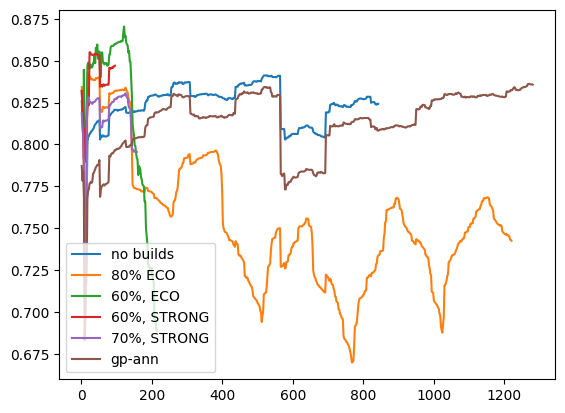

In [162]:
mode = "RecallTarget"
param = .9
gpann_param = 7

plt.plot(surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == mode) &
        (surge_no_rebuilds["param"] == param)
    ]["step"],
    surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == mode) &
        (surge_no_rebuilds["param"] == param)
    ]["recall@10"], label="no builds")

plt.plot(surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == mode) &
        (surge_t80["param"] == param)
    ]["step"],
    surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == mode) &
        (surge_t80["param"] == param)
    ]["recall@10"], label="80% ECO")

plt.plot(surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == mode) &
        (surge_t60["param"] == param)
    ]["step"],
    surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == mode) &
        (surge_t60["param"] == param)
    ]["recall@10"], label="60%, ECO")

plt.plot(surge_t60_strong[
        (surge_t60_strong["operation"] == "search") &
        (surge_t60_strong["mode"] == mode) &
        (surge_t60_strong["param"] == param)
    ]["step"],
    surge_t60_strong[
        (surge_t60_strong["operation"] == "search") &
        (surge_t60_strong["mode"] == mode) &
        (surge_t60_strong["param"] == param)
    ]["recall@10"], label="60%, STRONG")

plt.plot(surge_t70_strong[
        (surge_t70_strong["operation"] == "search") &
        (surge_t70_strong["mode"] == mode) &
        (surge_t70_strong["param"] == param)
    ]["step"],
    surge_t70_strong[
        (surge_t70_strong["operation"] == "search") &
        (surge_t70_strong["mode"] == mode) &
        (surge_t70_strong["param"] == param)
    ]["recall@10"], label="70%, STRONG")

plt.plot(gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == gpann_param)
    ]["step"],
    gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == gpann_param)
    ]["recall@10"], label="gp-ann")

plt.legend()

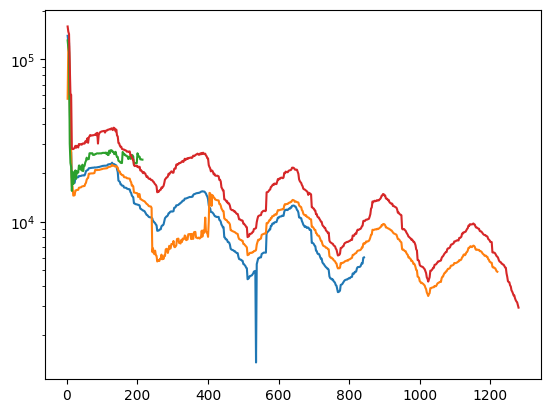

In [163]:
plt.plot(surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == "RecallTarget") &
        (surge_no_rebuilds["param"] == .9)
    ]["step"],
    surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == "RecallTarget") &
        (surge_no_rebuilds["param"] == .9)
    ]["throughput"])

plt.plot(surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == "RecallTarget") &
        (surge_t80["param"] == .9)
    ]["step"],
    surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == "RecallTarget") &
        (surge_t80["param"] == .9)
    ]["throughput"])

plt.plot(surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == "RecallTarget") &
        (surge_t60["param"] == .9)
    ]["step"],
    surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == "RecallTarget") &
        (surge_t60["param"] == .9)
    ]["throughput"])

plt.plot(gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == 7)
    ]["step"],
    gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == 7)
    ]["qps_or_throughput"])

plt.yscale("log")

In [102]:
gpann_results

,step,operation,nprobe,range_start,range_end,time_s,qps_or_throughput,recall@10,shard_0_size,shard_1_size,shard_2_size,shard_3_size,shard_4_size,shard_5_size,shard_6_size,shard_7_size,shard_8_size,shard_9_size,gini
0,1,BUILD,NaN,0,178387,0.884379,201709.00,NaN,18729,18729,18526,18729,18002,18729,18704,17246,17416,13577,0.036815
1,2,SEARCH,1.0,0,10000,0.021190,471931.00,0.27185,18729,18729,18526,18729,18002,18729,18704,17246,17416,13577,0.036815
2,2,SEARCH,2.0,0,10000,0.030186,331284.00,0.41139,18729,18729,18526,18729,18002,18729,18704,17246,17416,13577,0.036815
3,2,SEARCH,3.0,0,10000,0.043540,229672.00,0.51376,18729,18729,18526,18729,18002,18729,18704,17246,17416,13577,0.036815
4,2,SEARCH,4.0,0,10000,0.058071,172202.00,0.59791,18729,18729,18526,18729,18002,18729,18704,17246,17416,13577,0.036815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,1280,SEARCH,6.0,0,10000,3.113990,3211.31,0.79104,8158460,6868317,8553524,14280247,9250921,6408222,9438955,8079307,20539533,8422343,0.189272
7036,1280,SEARCH,7.0,0,10000,3.393940,2946.43,0.83569,8158460,6868317,8553524,14280247,9250921,6408222,9438955,8079307,20539533,8422343,0.189272
7037,1280,SEARCH,8.0,0,10000,3.624060,2759.33,0.87256,8158460,6868317,8553524,14280247,9250921,6408222,9438955,8079307,20539533,8422343,0.189272
7038,1280,SEARCH,9.0,0,10000,3.827420,2612.73,0.90246,8158460,6868317,8553524,14280247,9250921,6408222,9438955,8079307,20539533,8422343,0.189272


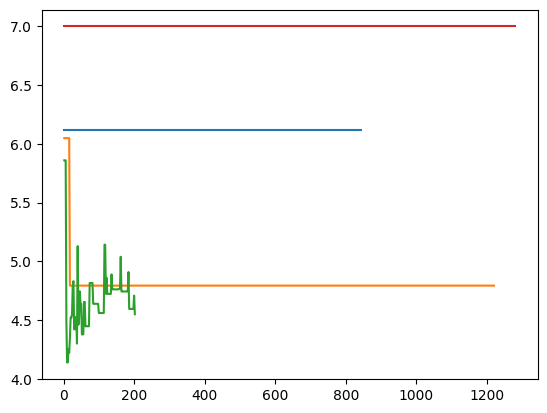

In [103]:
plt.plot(surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == "RecallTarget") &
        (surge_no_rebuilds["param"] == .9)
    ]["step"],
    surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == "RecallTarget") &
        (surge_no_rebuilds["param"] == .9)
    ]["avg_parts_searched"])

plt.plot(surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == "RecallTarget") &
        (surge_t80["param"] == .9)
    ]["step"],
    surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == "RecallTarget") &
        (surge_t80["param"] == .9)
    ]["avg_parts_searched"])

plt.plot(surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == "RecallTarget") &
        (surge_t60["param"] == .9)
    ]["step"],
    surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == "RecallTarget") &
        (surge_t60["param"] == .9)
    ]["avg_parts_searched"])

plt.plot(gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == 7)
    ]["step"],
    gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == 7)
    ]["nprobe"])

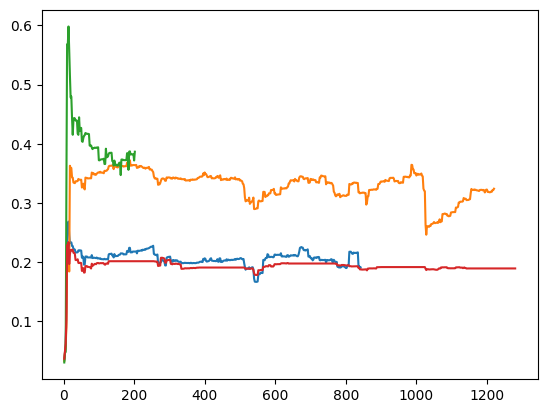

In [104]:
plt.plot(surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == "RecallTarget") &
        (surge_no_rebuilds["param"] == .9)
    ]["step"],
    surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == "RecallTarget") &
        (surge_no_rebuilds["param"] == .9)
    ]["gini"])

plt.plot(surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == "RecallTarget") &
        (surge_t80["param"] == .9)
    ]["step"],
    surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == "RecallTarget") &
        (surge_t80["param"] == .9)
    ]["gini"])

plt.plot(surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == "RecallTarget") &
        (surge_t60["param"] == .9)
    ]["step"],
    surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == "RecallTarget") &
        (surge_t60["param"] == .9)
    ]["gini"])

plt.plot(gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == 7)
    ]["step"],
    gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == 7)
    ]["gini"])